# Check frozen core (AGFN)

Analogous to RxnFlow's `notebooks/06_check_frozen_core.ipynb`. We seed generation with a
fixed molecule whose **core is held immutable**, grow molecules from it, and verify the core
stays intact throughout generation.

**How AGFN freezes the core (atom-index method).** AGFN builds molecules atom-by-atom on a
`networkx` graph, assigning each new atom the label `max(nodes)+1` and never renumbering. So
the seed molecule's atoms keep node labels `0..N-1` (= 0-based RDKit parse order) for the whole
trajectory. `build_frozen_seed_graph` stamps `g.graph['frozen_seed_size']` and
`g.graph['frozen_growth_sites']` onto the seed; `graph_to_Data` masks any action that would
edit the core, and `GraphBuildingEnv.step` asserts the same as a safety net.

Two independent checks per generated molecule:
- **Check A (exact):** the subgraph induced on labels `0..N-1` equals the seed (atoms, bonds, attrs).
- **Check B (chemistry):** `generated_mol.HasSubstructMatch(seed_mol)`.

In [1]:
import os, sys

# Put the repo's src/ on the path whether this runs from notebooks/ or the repo root.
for cand in ('../src', 'src', '../../src'):
    p = os.path.abspath(cand)
    if os.path.isdir(os.path.join(p, 'gflownet')):
        sys.path.insert(0, p)
        break

import torch
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog('rdApp.*')

from agfn.sampling import Sampler
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

molbuildingenv.py c import error


/home/aid/dkoh/third_party/AGFN/src/gflownet/envs/mol_building_env.py:27: UserWarning: Could not import mol_graph_to_Data, Graph, GraphDef from _C, using pure python implementation
  warnings.warn("Could not import mol_graph_to_Data, Graph, GraphDef from _C, using pure python implementation")


## Configuration

`SEED_SMILES` must use only atoms in the checkpoint's atom set (`['Br','C','Cl','F','I','N','O','S']`) and be smaller than `max_nodes` (45) to leave room to
grow. `GROWTH_ATOMS` are the 0-based seed atom indices where new atoms may attach; every other
core atom is frozen. Set `GROWTH_ATOMS = None` to freeze the whole core but allow growth at any
atom, or swap to `FROZEN_ATOMS = [...]` to name the atoms to freeze instead.

In [36]:
CKPT = "/home/aid/dkoh/log/generative/trash/braf_RTB_Denovo_20260527_174606/model_state_braf_RTB_Denovo_20260527_174606_17400.pt"
SEED_SMILES = "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O"   # benzene; swap for any seed over the model's atom set
GROWTH_ATOMS = [0]          # grow only off atom 0; the other 5 ring atoms stay frozen
FROZEN_ATOMS = None         # alternative: name atoms to freeze instead (mutually exclusive)
N_SAMPLES = 128

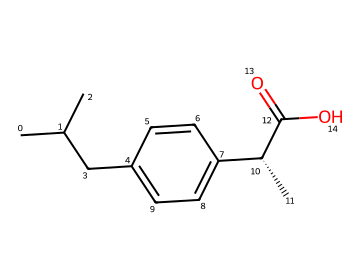

In [37]:
# 2D structure with each atom's index annotated — read off the numbers you want to freeze.
seed = Chem.MolFromSmiles(SEED_SMILES)
labeled = Chem.Mol(seed)
for atom in labeled.GetAtoms():
    atom.SetProp("atomNote", str(atom.GetIdx()))

d = rdMolDraw2D.MolDraw2DSVG(360, 280)
rdMolDraw2D.PrepareAndDrawMolecule(d, labeled)
d.FinishDrawing()
SVG(d.GetDrawingText())

In [38]:
sampler = Sampler(
    model_load_path=CKPT,
    initial_scaffold=SEED_SMILES,
    allowed_growth_atoms=GROWTH_ATOMS,
    frozen_atoms=FROZEN_ATOMS,
)
seed = sampler.seed_graph
N = seed.graph['frozen_seed_size']
growth_sites = seed.graph['frozen_growth_sites']
print(f'seed = {SEED_SMILES!r}: {N} core atoms, growth sites = {sorted(growth_sites)}')

[frozen-core] seed 'CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O': 15 core atoms, 1 growth site(s).
len loaded dict: 419
seed = 'CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O': 15 core atoms, growth sites = [0]


## Sample

Call `sample_from_model` directly (rather than `sample_smiles`) so we can inspect each final
trajectory **graph**, which Check A needs.

In [39]:
cond = sampler.cond_info_cmp.compute_cond_info_forward(N_SAMPLES)
enc = sampler.cond_info_cmp.thermometer_encoding(cond).to(sampler.device)
with torch.no_grad():
    res = sampler.graph_sampler.sample_from_model(
        sampler.model, N_SAMPLES, enc, sampler.device,
        random_stop_action_prob=sampler.hps['random_stop_prob'],
        random_action_prob=sampler.hps['random_action_prob'],
        seed_graph=sampler.seed_graph,
    )

valid = [r for r in res if r['is_valid'] and 'fwd_logprob' in r]
graphs = [r['traj'][-1][0] for r in valid]
mols = [sampler.ctx.graph_to_mol(g) for g in graphs]
grew = sum(len(g.nodes) > N for g in graphs)
print(f'valid trajectories: {len(valid)}/{N_SAMPLES}   |   grew beyond seed: {grew}/{len(graphs)}')

valid trajectories: 128/128   |   grew beyond seed: 128/128


## Check A — exact core subgraph

Since seed atoms keep labels `0..N-1`, compare the induced subgraph on those labels (atoms,
bonds, and their attribute dicts) against the seed. This is the strict invariant the masks +
step guards enforce.

In [40]:
def core_intact_graph(g):
    if not all(k in g.nodes for k in range(N)):
        return False
    for k in range(N):
        if dict(g.nodes[k]) != dict(seed.nodes[k]):
            return False
    seed_edges = {frozenset(e): dict(seed.edges[e]) for e in seed.edges if e[0] < N and e[1] < N}
    g_edges = {frozenset(e): dict(g.edges[e]) for e in g.edges if e[0] < N and e[1] < N}
    return seed_edges == g_edges

a_pass = sum(core_intact_graph(g) for g in graphs)
print(f'Check A (exact core subgraph): {a_pass}/{len(graphs)} = {100.0 * a_pass / max(len(graphs), 1):.1f}%')

Check A (exact core subgraph): 128/128 = 100.0%


## Check B — RDKit substructure match

A chemistry-level cross-check: the generated molecule must contain the seed as a substructure.

In [41]:
seed_mol = Chem.MolFromSmiles(SEED_SMILES)
b_pass = sum(m is not None and m.HasSubstructMatch(seed_mol) for m in mols)
print(f'Check B (substructure match): {b_pass}/{len(mols)} = {100.0 * b_pass / max(len(mols), 1):.1f}%')

Check B (substructure match): 128/128 = 100.0%


## Summary

In [42]:
print(f'valid           : {len(valid)}/{N_SAMPLES}')
print(f'grew beyond seed: {grew}/{len(graphs)}')
print(f'Check A (exact) : {a_pass}/{len(graphs)}')
print(f'Check B (substr): {b_pass}/{len(mols)}')
assert len(graphs) > 0, 'no valid molecules generated'
assert a_pass == len(graphs), 'frozen core was edited in at least one molecule!'
print('\nPASS: every generated molecule kept the frozen core intact.')

valid           : 128/128
grew beyond seed: 128/128
Check A (exact) : 128/128
Check B (substr): 128/128

PASS: every generated molecule kept the frozen core intact.


## Visualize

A few grown molecules with the frozen core highlighted. The core atoms keep RDKit indices
`0..N-1` in the generated molecule (the graph builder preserves node order), so we highlight
exactly those.

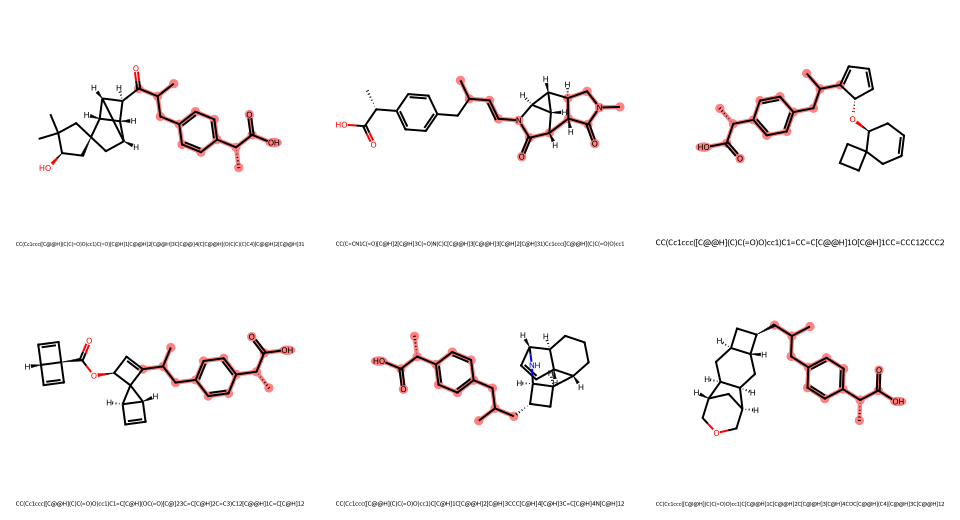

In [43]:
show = [m for m in mols if m is not None and m.GetNumAtoms() > N][:6]
img = Draw.MolsToGridImage(
    show,
    molsPerRow=3,
    subImgSize=(320, 260),
    highlightAtomLists=[list(range(N))] * len(show),
    legends=[Chem.MolToSmiles(m) for m in show],
    useSVG=False,
)
# MolsToGridImage may return a PIL.Image (.save) or an IPython Image (.data) depending on env.
if hasattr(img, 'save'):
    img.save('check_frozen_core_grid.png')
elif hasattr(img, 'data'):
    open('check_frozen_core_grid.png', 'wb').write(img.data)
img

In [44]:
show = [m for m in mols if m is not None and m.GetNumAtoms() > N][:6]
imgs = []
for mol in show:
    labeled = Chem.Mol(mol)
    for atom in labeled.GetAtoms():
        atom.SetProp("atomNote", str(atom.GetIdx()))

    d = rdMolDraw2D.MolDraw2DSVG(360, 280)
    highlight_atoms = list(range(N))
    rdMolDraw2D.PrepareAndDrawMolecule(d, labeled, highlightAtoms=highlight_atoms)
    d.FinishDrawing()
    imgs.append(SVG(d.GetDrawingText()))

In [45]:
list(range(N))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [46]:
imgs

[<IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>,
 <IPython.core.display.SVG object>]

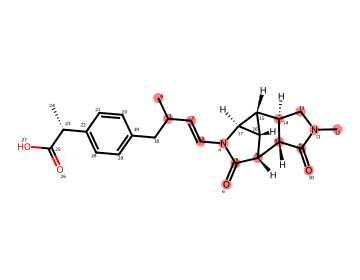

In [47]:
imgs[1]